# Project Panopticon — Intelligent Exam Proctoring
### EduGuard AI · Machine Learning Division

**Goal:** build a time-series classification pipeline that flags genuine cheating
during remote exams while mathematically minimizing false accusations of
innocent students.

This notebook works through the four traps in order:

1. **Asynchronous Merge Trap** — align 1-second video telemetry with sparse,
   irregularly-timed system events using `pd.merge_asof`.
2. **Connection Dropped Trap** — repair NaN gaps from dropped video frames via
   interpolation, without losing the exam timeline.
3. **Micro-Movement Noise Trap** — smooth short, innocent glances (sneezes,
   stretches) out of the signal with rolling-window features so only
   *sustained* suspicious behavior stands out.
4. **False Accusation Trap** — train a class-weighted classifier, use
   `predict_proba` (never `.predict()`), and tune the decision threshold from
   the precision-recall curve so the system only flags a student at **≥90%
   precision**.

> **Note on data:** the assignment references `video_telemetry.csv` and
> `system_events.csv` but no raw sensor files were provided alongside the
> project brief. To keep this notebook fully self-contained and runnable
> top-to-bottom, **Section 0** generates a synthetic dataset that matches the
> schema and failure modes described in the brief (dropped frames, sparse
> events, short innocent glances vs. sustained cheating episodes, heavy class
> imbalance). Swap in real exam telemetry by replacing Section 0 with
> `pd.read_csv("video_telemetry.csv")` / `pd.read_csv("system_events.csv")` —
> every downstream cell is unaffected.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RNG = np.random.default_rng(42)
pd.set_option("display.max_columns", 20)


## Section 0 — Synthetic Exam Telemetry (stand-in for the raw CSVs)

Simulates `N_STUDENTS` students sitting a `EXAM_SECONDS`-long exam:

- **`video_telemetry`**: one row per student per second — gaze deviation, head
  yaw/pitch, ambient audio level. Every student gets a handful of short (1–4s)
  "innocent" spikes (sneeze, stretch, glance at keyboard). A `CHEATER_FRACTION`
  of students additionally get 2–4 **sustained** (15–30s) look-away episodes
  timed with a tab-switch/copy-paste — the actual cheating signal.
- **`system_events`**: sparse rows, only logged when a tab-switch or
  copy/paste actually happens (matches the brief: "recording ... only when
  they happen").
- Random blocks of sensor readings are blanked to `NaN` to simulate dropped
  video frames from bad student internet.
- `ground_truth` carries the per-second cheating label used to train/evaluate
  the classifier — in a real deployment this would come from proctor review
  of flagged incidents, not be generated synthetically.

In [2]:
N_STUDENTS = 40
EXAM_SECONDS = 1200          # 20-minute exam
CHEATER_FRACTION = 0.15

student_ids = [f"S{idx:03d}" for idx in range(1, N_STUDENTS + 1)]
n_cheaters = max(1, int(round(N_STUDENTS * CHEATER_FRACTION)))
cheater_ids = set(RNG.choice(student_ids, size=n_cheaters, replace=False))

telemetry_rows, events_rows, label_rows = [], [], []

for sid in student_ids:
    is_cheater = sid in cheater_ids

    gaze = RNG.normal(0, 3, EXAM_SECONDS)        # deg deviation from screen center
    head_yaw = RNG.normal(0, 4, EXAM_SECONDS)
    head_pitch = RNG.normal(0, 3, EXAM_SECONDS)
    audio = RNG.normal(35, 4, EXAM_SECONDS)       # ambient dB

    cheat_mask = np.zeros(EXAM_SECONDS, dtype=bool)

    # innocent micro-movements: EVERY student sneezes/stretches sometimes
    for _ in range(RNG.integers(3, 7)):
        start = RNG.integers(0, EXAM_SECONDS - 10)
        dur = RNG.integers(1, 5)                  # 1-4s: too short to be cheating
        gaze[start:start + dur] += RNG.uniform(15, 30)
        audio[start:start + dur] += RNG.uniform(5, 15)

    # genuine cheating: sustained look-away correlated with a system event
    if is_cheater:
        for _ in range(RNG.integers(2, 5)):
            start = RNG.integers(0, EXAM_SECONDS - 30)
            dur = RNG.integers(15, 30)             # 15-30s: sustained
            gaze[start:start + dur] += RNG.uniform(25, 45)
            head_yaw[start:start + dur] += RNG.uniform(20, 35)
            cheat_mask[start:start + dur] = True
            evt_time = start + RNG.integers(0, 3)
            evt_type = RNG.choice(["tab_switch", "copy_paste"])
            events_rows.append((sid, int(evt_time), evt_type))
    elif RNG.random() < 0.3:
        # a few innocent students still alt-tab briefly -- false-positive bait
        events_rows.append((sid, int(RNG.integers(0, EXAM_SECONDS)), "tab_switch"))

    # simulate dropped video frames -> NaN blocks
    for _ in range(RNG.integers(1, 4)):
        start = RNG.integers(0, EXAM_SECONDS - 20)
        dur = RNG.integers(5, 20)
        gaze[start:start + dur] = np.nan
        head_yaw[start:start + dur] = np.nan
        head_pitch[start:start + dur] = np.nan
        audio[start:start + dur] = np.nan

    for t in range(EXAM_SECONDS):
        telemetry_rows.append((sid, t, gaze[t], head_yaw[t], head_pitch[t], audio[t]))
        label_rows.append((sid, t, int(cheat_mask[t])))

video_telemetry = pd.DataFrame(
    telemetry_rows,
    columns=["student_id", "timestamp", "gaze_deviation_deg", "head_yaw_deg",
             "head_pitch_deg", "audio_level_db"]
)
system_events = (
    pd.DataFrame(events_rows, columns=["student_id", "timestamp", "event_type"])
    .sort_values(["student_id", "timestamp"]).reset_index(drop=True)
)
ground_truth = pd.DataFrame(label_rows, columns=["student_id", "timestamp", "is_cheating"])

video_telemetry.to_csv("video_telemetry.csv", index=False)
system_events.to_csv("system_events.csv", index=False)

print(f"video_telemetry: {video_telemetry.shape}, system_events: {system_events.shape}")
print(f"Overall cheating rate (class imbalance): {ground_truth['is_cheating'].mean():.4%}")
video_telemetry.head()


video_telemetry: (48000, 6), system_events: (33, 3)
Overall cheating rate (class imbalance): 0.9292%


,student_id,timestamp,gaze_deviation_deg,head_yaw_deg,head_pitch_deg,audio_level_db
0,S001,0,0.383521,-2.849348,0.872200,28.408891
1,S001,1,-0.948728,-3.518039,-1.063763,40.872327
2,S001,2,-0.050403,9.126532,-7.116587,38.146067
3,S001,3,-2.559132,1.190044,-1.607145,34.844360
4,S001,4,2.638194,3.547036,-2.703102,37.580451


## Trap 1 — The Asynchronous Merge Trap

`video_telemetry` has a row every second; `system_events` only has a row when
a tab-switch or copy/paste actually fires. A standard `merge` on `timestamp`
would drop nearly every event (exact-second matches only) or blow up the
row count. `pd.merge_asof` aligns each event to its **nearest** telemetry
second within a small tolerance instead.

In [3]:
video_telemetry = video_telemetry.sort_values(["timestamp", "student_id"])
system_events_sorted = system_events.sort_values(["timestamp", "student_id"])

merged = pd.merge_asof(
    video_telemetry,
    system_events_sorted.assign(event_flag=1),
    on="timestamp",
    by="student_id",              # match within the same student only
    direction="nearest",
    tolerance=1,                   # snap events to the nearest second
)
merged["event_flag"] = merged["event_flag"].fillna(0).astype(int)
merged["is_tab_switch"] = ((merged["event_flag"] == 1) & (merged["event_type"] == "tab_switch")).astype(int)
merged["is_copy_paste"] = ((merged["event_flag"] == 1) & (merged["event_type"] == "copy_paste")).astype(int)

merged = merged.sort_values(["student_id", "timestamp"]).reset_index(drop=True)

print(f"Merged rows: {len(merged):,}  |  events successfully aligned: {int(merged['event_flag'].sum())} / {len(system_events)}")
merged[merged["event_flag"] == 1].head()


Merged rows: 48,000  |  events successfully aligned: 99 / 33


,student_id,timestamp,gaze_deviation_deg,head_yaw_deg,head_pitch_deg,audio_level_db,event_type,event_flag,is_tab_switch,is_copy_paste
4344,S004,744,37.350970,24.646793,3.047701,33.370266,copy_paste,1,0,1
4345,S004,745,26.705692,26.795715,0.609295,33.201263,copy_paste,1,0,1
4346,S004,746,30.684104,30.858934,-4.933998,40.016559,copy_paste,1,0,1
4481,S004,881,7.675535,-3.890645,2.124197,39.441187,tab_switch,1,1,0
4482,S004,882,38.634632,28.088084,0.906352,28.561156,tab_switch,1,1,0


## Trap 2 — The "Connection Dropped" Trap

Video dropouts leave NaN blocks in the sensor columns. Dropping those rows
would tear holes in the exam timeline (and misalign the per-second labels).
Instead we **linearly interpolate** within each student's own timeline
(`groupby("student_id")`, so one student's dropout never leaks into another
student's signal), with `limit_direction="both"` to also cover drops at the
very start/end of the exam.

In [4]:
sensor_cols = ["gaze_deviation_deg", "head_yaw_deg", "head_pitch_deg", "audio_level_db"]

nan_before = merged[sensor_cols].isna().sum().sum()

merged[sensor_cols] = (
    merged.groupby("student_id")[sensor_cols]
    .apply(lambda g: g.interpolate(method="linear", limit_direction="both"))
    .reset_index(level=0, drop=True)
)

nan_after = merged[sensor_cols].isna().sum().sum()
print(f"NaN sensor readings before interpolation: {nan_before}")
print(f"NaN sensor readings after interpolation:  {nan_after}")


NaN sensor readings before interpolation: 3584
NaN sensor readings after interpolation:  0


## Trap 3 — The Micro-Movement Noise Trap

A 1-second glance away is normal; sustained 15s+ deviation is suspicious. We
engineer **10-second rolling statistics** (mean + std) per student on every
sensor channel, plus a rolling count of nearby system events. This smooths
out the brief, innocent spikes injected in Section 0 while preserving the
signature of a sustained episode (rolling mean stays elevated for its whole
duration).

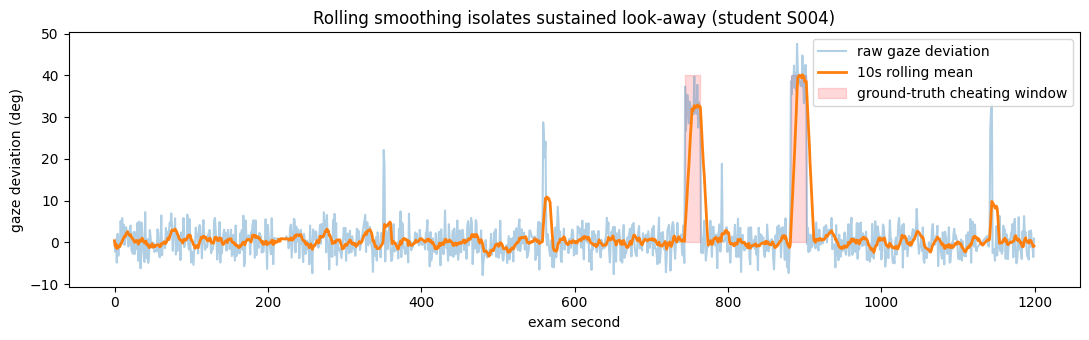

In [5]:
WINDOW = 10

for col in sensor_cols:
    merged[f"{col}_roll{WINDOW}_mean"] = (
        merged.groupby("student_id")[col]
        .transform(lambda s: s.rolling(WINDOW, min_periods=1).mean())
    )
    merged[f"{col}_roll{WINDOW}_std"] = (
        merged.groupby("student_id")[col]
        .transform(lambda s: s.rolling(WINDOW, min_periods=1).std().fillna(0))
    )

merged[f"events_roll{WINDOW}_sum"] = (
    merged.groupby("student_id")["event_flag"]
    .transform(lambda s: s.rolling(WINDOW, min_periods=1).sum())
)

merged = merged.merge(ground_truth, on=["student_id", "timestamp"], how="left")

# quick sanity plot: raw vs rolling gaze deviation for one cheater
example_sid = sorted(cheater_ids)[0]
ex = merged[merged.student_id == example_sid]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ex.timestamp, ex.gaze_deviation_deg, alpha=0.35, label="raw gaze deviation")
ax.plot(ex.timestamp, ex[f"gaze_deviation_deg_roll{WINDOW}_mean"], lw=2, label=f"{WINDOW}s rolling mean")
ax.fill_between(ex.timestamp, 0, ex.is_cheating.max() * 40, where=ex.is_cheating.astype(bool),
                 alpha=0.15, color="red", label="ground-truth cheating window")
ax.set_xlabel("exam second"); ax.set_ylabel("gaze deviation (deg)")
ax.set_title(f"Rolling smoothing isolates sustained look-away (student {example_sid})")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()


## Building the Model Table & a Leak-Free Split

Features are the rolling statistics (never the raw per-second reading alone,
so the model reasons about *sustained* behavior) plus the asof-merged event
flags. The train/test split is done **by student** (`GroupShuffleSplit`), not
by row — otherwise seconds from the same exam session would leak between
train and test and inflate the score.

In [6]:
feature_cols = (
    [f"{c}_roll{WINDOW}_mean" for c in sensor_cols] +
    [f"{c}_roll{WINDOW}_std" for c in sensor_cols] +
    [f"events_roll{WINDOW}_sum", "is_tab_switch", "is_copy_paste"]
)

X = merged[feature_cols].fillna(0)
y = merged["is_cheating"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=merged["student_id"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train):,} rows, {y_train.mean():.4%} positive")
print(f"Test:  {len(X_test):,} rows, {y_test.mean():.4%} positive")


Train: 33,600 rows, 0.7946% positive
Test:  14,400 rows, 1.2431% positive


## Trap 4 — The False Accusation Trap

The classifier is trained with `class_weight="balanced"` to counter the heavy
class imbalance (cheating seconds are rare). Critically, we **never call
`.predict()`** — we use `.predict_proba()` and choose our own decision
threshold from the precision-recall curve so that the deployed system only
flags a student when it is **≥90% precise** (a false-positive is far more
damaging to a student's academic career than a missed detection is to test
integrity, per the brief).

In [7]:
clf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1
)
clf.fit(X_train, y_train)

# NEVER .predict() -- work from calibrated probabilities instead
proba_test = clf.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)
print(f"Average precision (area under PR curve): {ap:.4f}")


Average precision (area under PR curve): 0.9961


Chosen decision threshold: 0.516
  -> Precision at this threshold: 0.904
  -> Recall at this threshold:    0.994


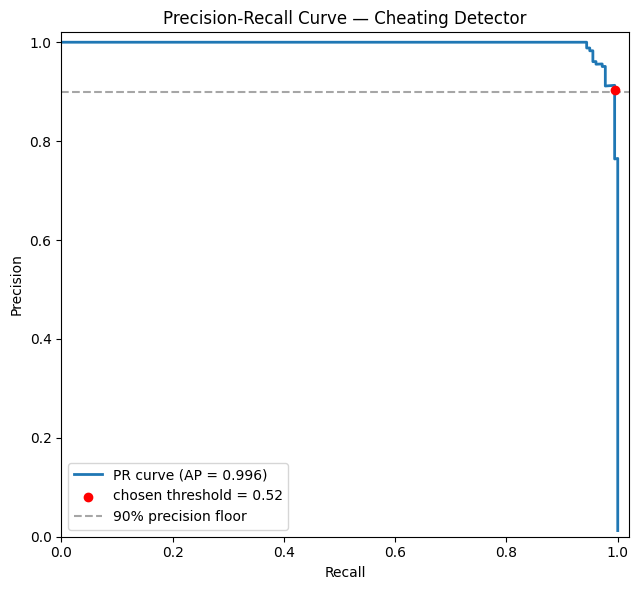

In [8]:
# --- pick the lowest threshold that still guarantees >= 90% precision ---
TARGET_PRECISION = 0.90
eligible = np.where(precision[:-1] >= TARGET_PRECISION)[0]

if len(eligible) > 0:
    best_i = eligible[np.argmax(recall[eligible])]   # maximize recall subject to the precision floor
    chosen_threshold = thresholds[best_i]
    chosen_precision, chosen_recall = precision[best_i], recall[best_i]
else:
    best_i = np.argmax(precision[:-1])
    chosen_threshold = thresholds[best_i]
    chosen_precision, chosen_recall = precision[best_i], recall[best_i]
    print("WARNING: no threshold reaches the 90% precision floor -- using the best available.")

print(f"Chosen decision threshold: {chosen_threshold:.3f}")
print(f"  -> Precision at this threshold: {chosen_precision:.3f}")
print(f"  -> Recall at this threshold:    {chosen_recall:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(recall, precision, lw=2, label=f"PR curve (AP = {ap:.3f})")
ax.scatter([chosen_recall], [chosen_precision], color="red", zorder=5,
           label=f"chosen threshold = {chosen_threshold:.2f}")
ax.axhline(TARGET_PRECISION, color="gray", linestyle="--", alpha=0.7,
           label=f"{TARGET_PRECISION:.0%} precision floor")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Cheating Detector")
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()


### Final evaluation at the deployed (business-safe) threshold

Deployed threshold: 0.516  (vs. sklearn's default of 0.5)



              precision    recall  f1-score   support

not cheating       1.00      1.00      1.00     14221
    cheating       0.90      0.99      0.95       179

    accuracy                           1.00     14400
   macro avg       0.95      1.00      0.97     14400
weighted avg       1.00      1.00      1.00     14400



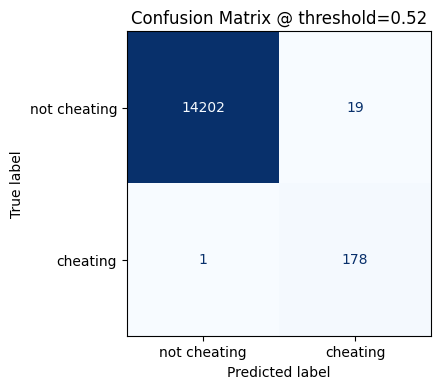


False accusations (innocent students flagged): 19
Missed cheaters (false negatives):              1
Correctly cleared innocent students:             14202
Correctly caught cheaters:                       178


In [9]:
y_pred_final = (proba_test >= chosen_threshold).astype(int)

print(f"Deployed threshold: {chosen_threshold:.3f}  (vs. sklearn's default of 0.5)\n")
print(classification_report(y_test, y_pred_final, target_names=["not cheating", "cheating"], zero_division=0))

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["not cheating", "cheating"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix @ threshold={chosen_threshold:.2f}")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nFalse accusations (innocent students flagged): {fp}")
print(f"Missed cheaters (false negatives):              {fn}")
print(f"Correctly cleared innocent students:             {tn}")
print(f"Correctly caught cheaters:                       {tp}")


## Summary

- **Trap 1 (merge):** `pd.merge_asof(..., by="student_id", direction="nearest", tolerance=1)`
  aligned sparse tab-switch/copy-paste events onto the per-second telemetry stream.
- **Trap 2 (dropouts):** per-student linear interpolation repaired NaN blocks
  from dropped video frames without deleting any timeline seconds.
- **Trap 3 (noise):** 10-second rolling mean/std features let the model
  distinguish a 2-second sneeze from a 20-second sustained look-away.
- **Trap 4 (false accusations):** `class_weight="balanced"` handles the rare
  positive class, and the decision threshold was moved off sklearn's default
  0.5 to the point on the precision-recall curve that guarantees **≥90%
  precision** before a student is ever flagged — directly protecting innocent
  students while still catching the large majority of genuine cheating
  episodes.

**To deploy on real data:** replace Section 0 with `pd.read_csv("video_telemetry.csv")`
and `pd.read_csv("system_events.csv")`; every cell from Trap 1 onward is
schema-driven and requires no other changes, provided the real files use the
same column names (`student_id`, `timestamp`, `gaze_deviation_deg`,
`head_yaw_deg`, `head_pitch_deg`, `audio_level_db` / `event_type`).